<a href="https://colab.research.google.com/github/asolergayoso/DS_5500_Ransomware_Detection/blob/tsnse_and_basic_classification/vis_and_class_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install umap-learn

In [87]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [84]:
df = pd.read_pickle("/content/final_dataset_with_first_logs_window_10s.pkl")
df.drop(["start", "end"], axis=1, inplace=True)
df["is_ransomware"] = df["is_ransomware"].astype(int)
df.fillna(-1, inplace=True)

features = df.drop(['is_ransomware', 'operation'], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

df_scaled['is_ransomware'] = df['is_ransomware']
df_scaled['operation'] = df['operation']

display(df_scaled.head())

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,num_MIMO_pages_mem_read_write,num_MIMO_pages_mem_exec,gpa_mem_read_var,gpa_mem_write_var,gpa_mem_read_write_var,gpa_mem_exec_var,start_s,end_s,is_ransomware,operation
0,-0.817815,-0.523550,0.544675,1.423664,0.611275,2.986587,0.771325,1.659701,-0.137167,-0.141189,...,0.0,0.0,8.538157,10.672768,1.461576,4.755281,-1.632991,-1.632991,0,AESCrypt
1,-0.817815,-0.523550,0.544675,1.423664,0.611275,0.150755,0.570950,-0.132360,-0.137167,-0.141189,...,0.0,0.0,0.829629,-0.107012,0.598858,4.239818,-1.616848,-1.616848,0,AESCrypt
2,-0.681411,-0.523506,-0.139544,1.431470,0.603422,-0.354916,-1.442968,-0.356367,-0.137167,-0.141189,...,0.0,0.0,-0.162933,-0.141981,-0.467328,1.181851,-1.600705,-1.600705,0,AESCrypt
3,-0.634527,-0.527431,-0.133113,-1.320410,-0.680367,-0.073775,0.625119,-0.356367,-0.137167,-0.141189,...,0.0,0.0,-0.053375,-0.132243,1.848370,0.818197,-1.584562,-1.584562,0,AESCrypt
4,-0.625779,-0.527519,-0.138930,-1.814302,-0.819170,-0.067706,0.625119,-0.356367,-0.137167,-0.141189,...,0.0,0.0,-0.047175,-0.129493,1.848370,0.818197,-1.568419,-1.568419,0,AESCrypt


# **Visualizations**

The following are some visualizations of the dataset using different dimensionality reduction techniques

### TSNE

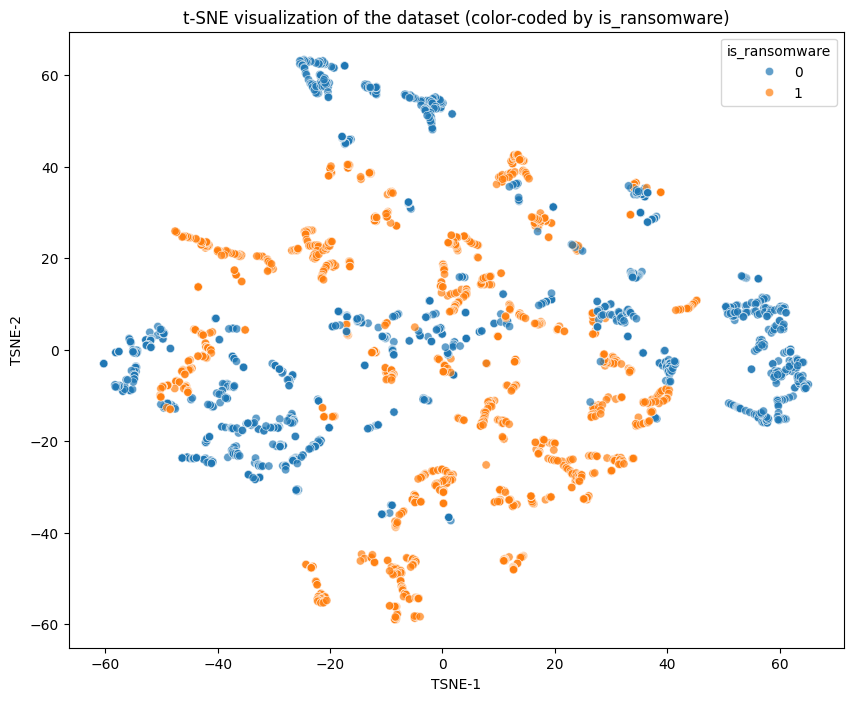

,TSNE-1,TSNE-2,is_ransomware,operation
0,24.526167,21.828642,0,AESCrypt
1,33.518227,35.261475,0,AESCrypt
2,35.997269,35.249134,0,AESCrypt
3,35.920921,33.577599,0,AESCrypt
4,36.030674,33.424694,0,AESCrypt


In [47]:
tsne_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(tsne_features)

df_tsne = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
df_tsne['is_ransomware'] = df_scaled['is_ransomware']
df_tsne['operation'] = df_scaled['operation']


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="is_ransomware",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the dataset (color-coded by is_ransomware)')
plt.show()

display(df_tsne.head())

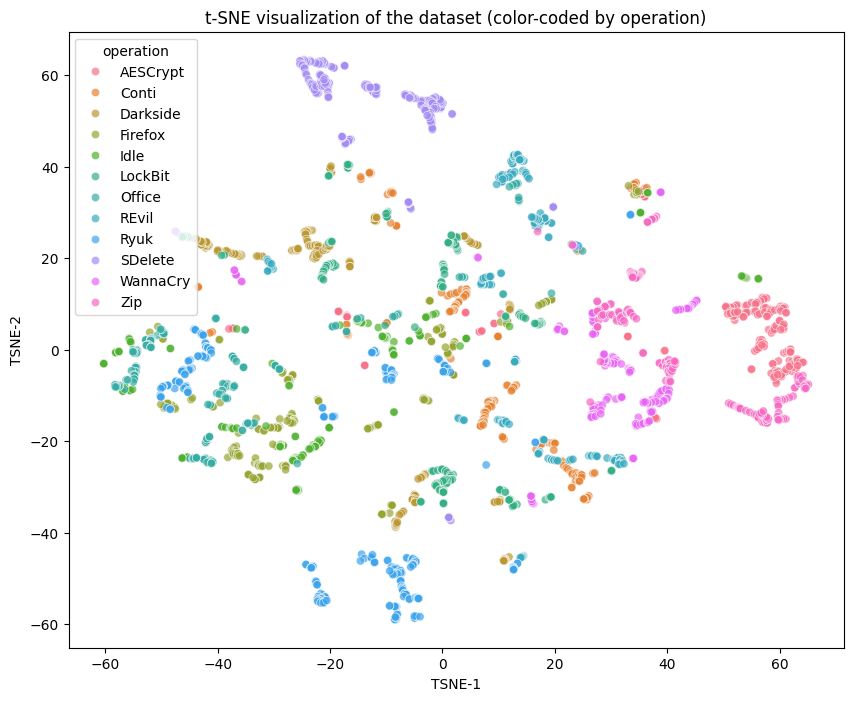

In [49]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="operation",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the dataset (color-coded by operation)')
plt.show()


## PCA with 2 components

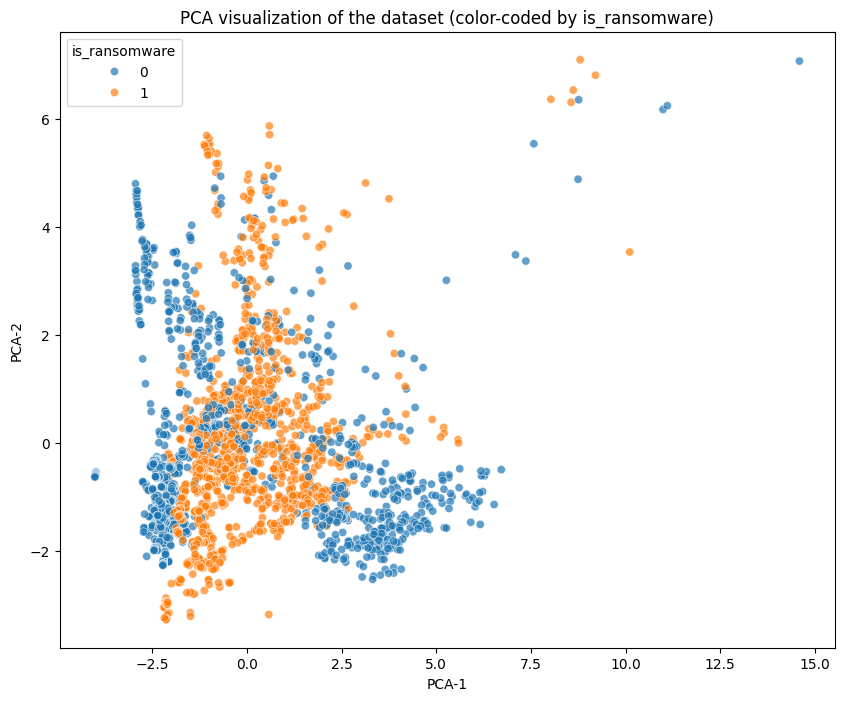

,PCA-1,PCA-2,is_ransomware
0,10.990509,6.178100,0
1,1.682527,2.304890,0
2,-0.494878,0.941123,0
3,0.510235,1.722420,0
4,0.507244,1.776014,0


In [50]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2'])
df_pca['is_ransomware'] = df_scaled['is_ransomware']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="PCA-1", y="PCA-2",
    hue="is_ransomware",
    data=df_pca,
    legend="full",
    alpha=0.7
)
plt.title('PCA visualization of the dataset (color-coded by is_ransomware)')
plt.show()

display(df_pca.head())

## PCA with 3 components

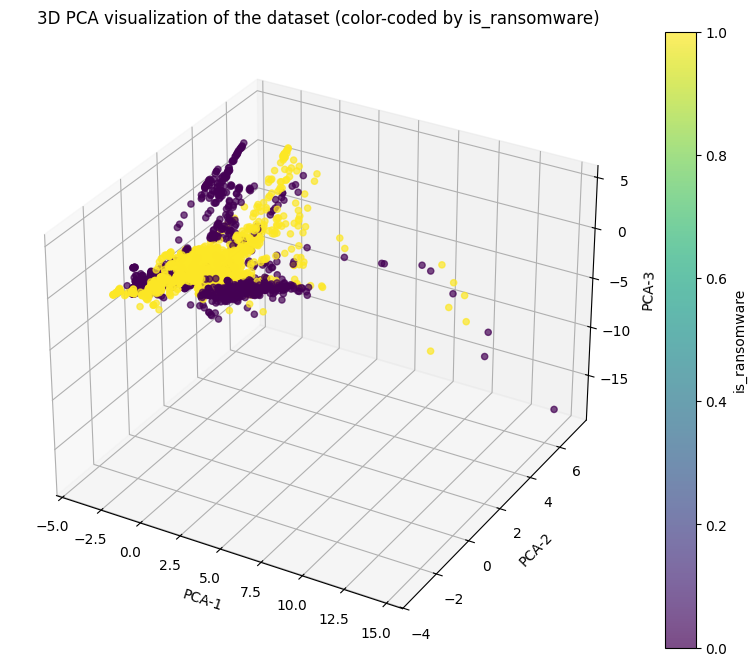

,PCA-1,PCA-2,PCA-3,is_ransomware
0,10.990509,6.178100,-12.907849,0
1,1.682527,2.304890,-5.028087,0
2,-0.494878,0.941123,-3.858236,0
3,0.510235,1.722420,-3.452436,0
4,0.507244,1.776014,-3.355753,0


In [51]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=3, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca_3d = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2', 'PCA-3'])
df_pca_3d['is_ransomware'] = df_scaled['is_ransomware']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pca_3d['PCA-1'],
    df_pca_3d['PCA-2'],
    df_pca_3d['PCA-3'],
    c=df_pca_3d['is_ransomware'],
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel('PCA-1')
ax.set_ylabel('PCA-2')
ax.set_zlabel('PCA-3')
plt.title('3D PCA visualization of the dataset (color-coded by is_ransomware)')
plt.colorbar(scatter, label='is_ransomware')
plt.show()

display(df_pca_3d.head())

## UMAP

In [59]:
umap_model = UMAP(n_components=2, random_state=42)

umap_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

umap_results = umap_model.fit_transform(umap_features)

df_umap = pd.DataFrame(umap_results, columns=['UMAP-1', 'UMAP-2'])

df_umap['is_ransomware'] = df_scaled['is_ransomware']
df_umap['operation'] = df_scaled['operation']

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


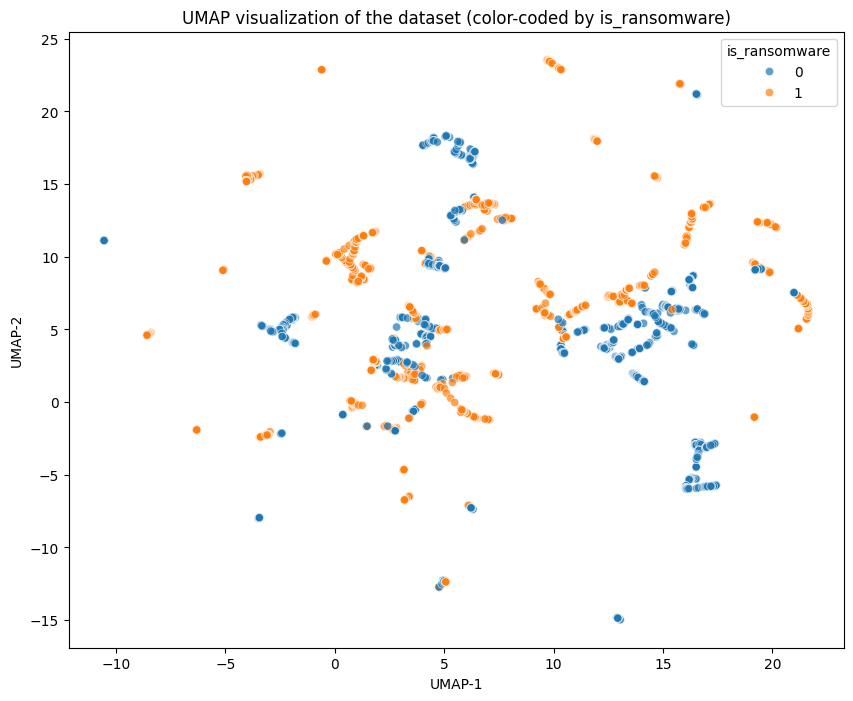

In [66]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="UMAP-1", y="UMAP-2",
    hue="is_ransomware",
    data=df_umap,
    legend="full",
    alpha=0.7
)
plt.title('UMAP visualization of the dataset (color-coded by is_ransomware)')
plt.show()


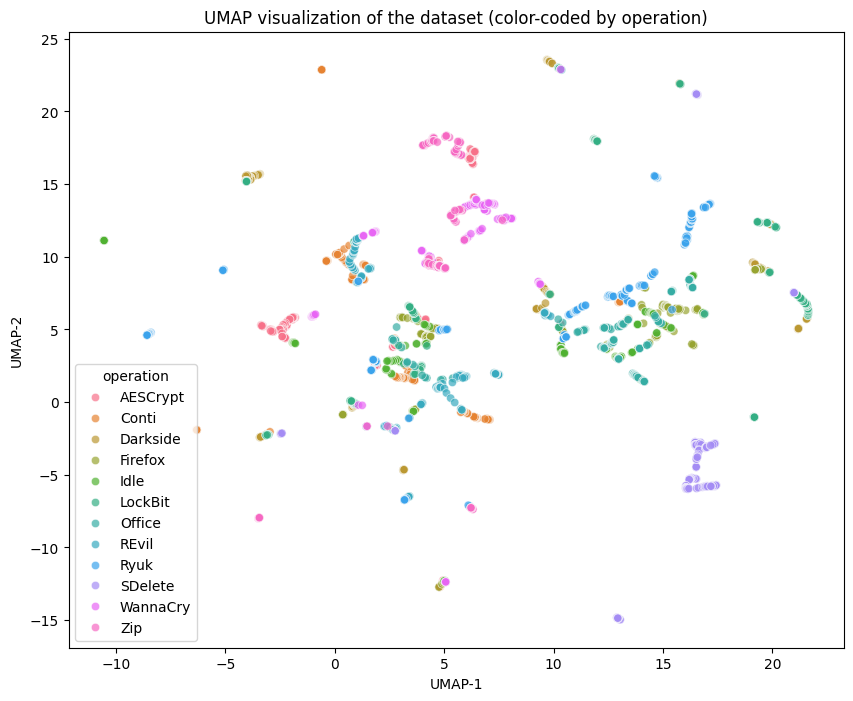

In [67]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="UMAP-1", y="UMAP-2",
    hue="operation",
    data=df_umap,
    legend="full",
    alpha=0.7
)
plt.title('UMAP visualization of the dataset (color-coded by operation)')
plt.show()

# **Classification**

Different models will be trained with the scaled data to get a basic sense of accuracy

In [35]:
features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)
target = df_scaled['is_ransomware']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [80]:
def evaluate(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))
  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
  disp.plot(cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.show()

### Decision Tree

                precision    recall  f1-score   support

Not Ransomware       0.95      0.98      0.97       216
    Ransomware       0.98      0.96      0.97       262

      accuracy                           0.97       478
     macro avg       0.97      0.97      0.97       478
  weighted avg       0.97      0.97      0.97       478



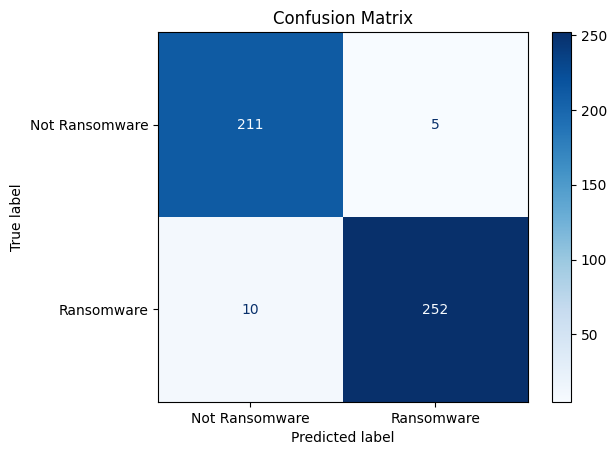

In [81]:
evaluate(DecisionTreeClassifier(random_state=42), X_train, y_train, X_test, y_test)

### Support Vector Machine

                precision    recall  f1-score   support

Not Ransomware       0.95      0.99      0.97       216
    Ransomware       0.99      0.96      0.97       262

      accuracy                           0.97       478
     macro avg       0.97      0.97      0.97       478
  weighted avg       0.97      0.97      0.97       478



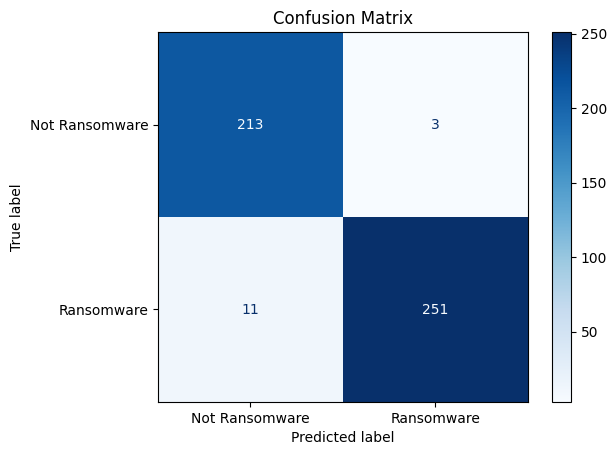

In [82]:
evaluate(SVC(random_state=42), X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                precision    recall  f1-score   support

Not Ransomware       0.94      0.98      0.96       216
    Ransomware       0.98      0.95      0.97       262

      accuracy                           0.96       478
     macro avg       0.96      0.97      0.96       478
  weighted avg       0.97      0.96      0.96       478



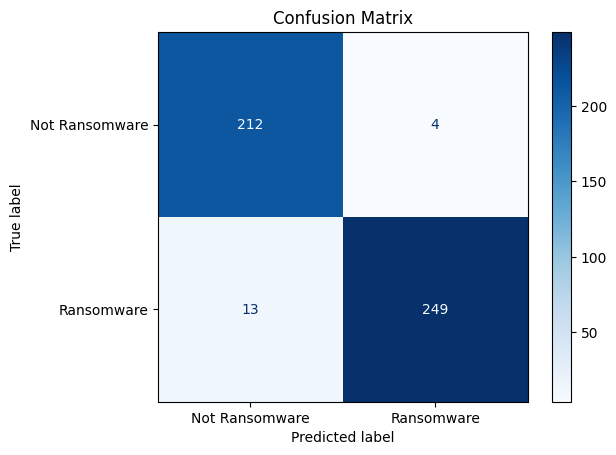

In [88]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()